In [1]:
import anndata as ad
import scanpy as sc
import hdf5plugin
import scipy
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
adamson_data = sc.read_h5ad(f"Data/AdamsonWeissman2016_GSM2406681_10X010/perturb_norm.h5ad")
norman_data = sc.read_h5ad(f"Data/NormanWeissman2019_filtered/perturb_norm.h5ad")
adamson_data.layers["log1p"] = adamson_data.layers["log1p"].tocsc()
adamson_data = adamson_data[adamson_data.obs["perturbation"]=="ctrl"]
norman_data = norman_data[norman_data.obs["perturbation"]=="ctrl"]

In [3]:
topo = "dorothea_tf2_abc"
replicate = "001"
path_to_data = f"Data/SimulResults_Racipe/{topo}/{replicate}/{topo}_steadystate_solutions_{replicate}"
grins_data_00 = sc.read_h5ad(f"{path_to_data}-0_0.h5ad")
grins_data_001 = sc.read_h5ad(f"{path_to_data}-0_01.h5ad")
grins_data_01 = sc.read_h5ad(f"{path_to_data}-0_1.h5ad")

# Plot Counts:

## Norman:

In [9]:
norman_mean = np.asarray(norman_data.layers["log1p"].mean(axis=0)).squeeze()
n_squared = norman_data.layers["log1p"].multiply(norman_data.layers["log1p"])
norman_var = np.asarray(np.mean(n_squared,axis=0)).squeeze()-norman_mean*norman_mean

r_norman_mean = np.asarray(norman_data.X.mean(axis=0)).squeeze()
r_n_squared = norman_data.X.multiply(norman_data.X)
r_norman_var = np.asarray(np.mean(r_n_squared,axis=0)).squeeze()-r_norman_mean*r_norman_mean

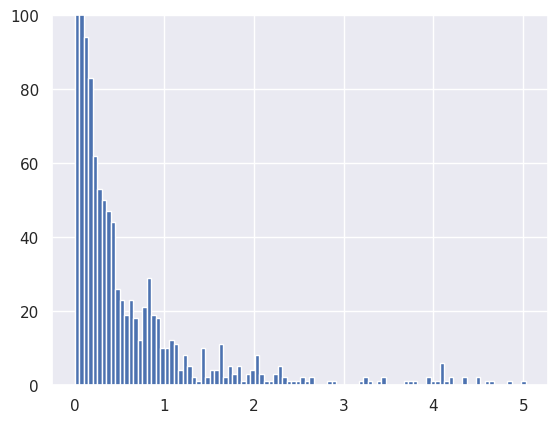

In [6]:
plt.hist(norman_mean,bins=100)
plt.ylim(0,100)
plt.show()

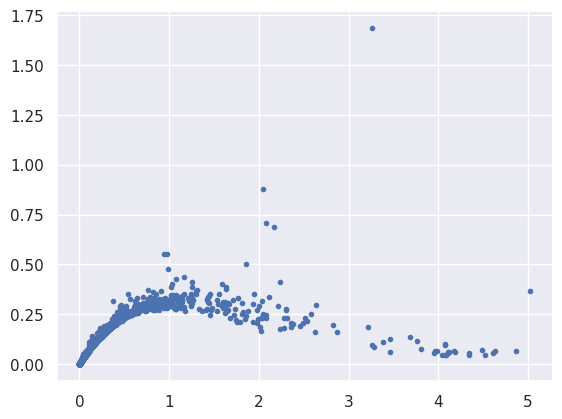

/tmp/ipykernel_13325/3989386553.py:3: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(r_norman_mean),np.log(r_norman_var),".")


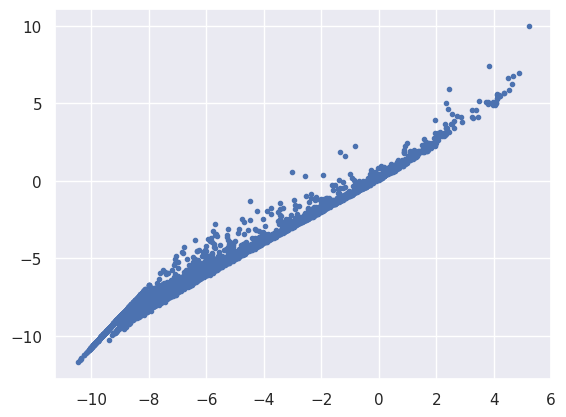

In [7]:
plt.plot(norman_mean,norman_var,".")
plt.show()
plt.plot(np.log(r_norman_mean),np.log(r_norman_var),".")
plt.show()

## GRiNS:

In [10]:
grins_mean = np.asarray(grins_data.layers["log1p"].mean(axis=0)).squeeze()
g_squared = grins_data.layers["log1p"].multiply(grins_data.layers["log1p"])
grins_var = np.asarray(np.mean(g_squared,axis=0)).squeeze()-grins_mean*grins_mean
"""
r_grins_mean = np.asarray(grins_data.X.mean(axis=0)).squeeze()
r_g_squared = grins_data.X.multiply(grins_data.X)
r_grins_var = np.asarray(np.mean(r_g_squared,axis=0)).squeeze()-r_grins_mean*r_grins_mean
"""

'\nr_grins_mean = np.asarray(grins_data.X.mean(axis=0)).squeeze()\nr_g_squared = grins_data.X.multiply(grins_data.X)\nr_grins_var = np.asarray(np.mean(r_g_squared,axis=0)).squeeze()-r_grins_mean*r_grins_mean\n'

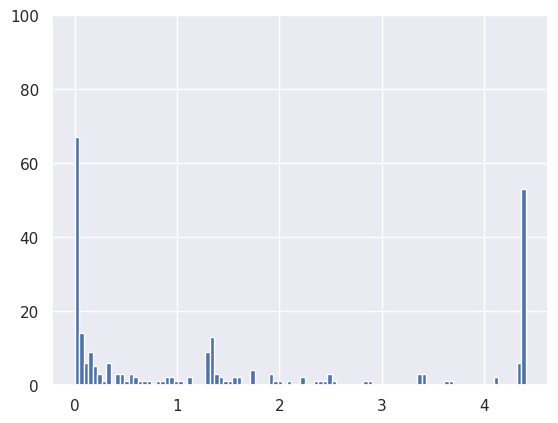

In [9]:
plt.hist(grins_mean,bins=100)
plt.ylim(0,100)
plt.show()

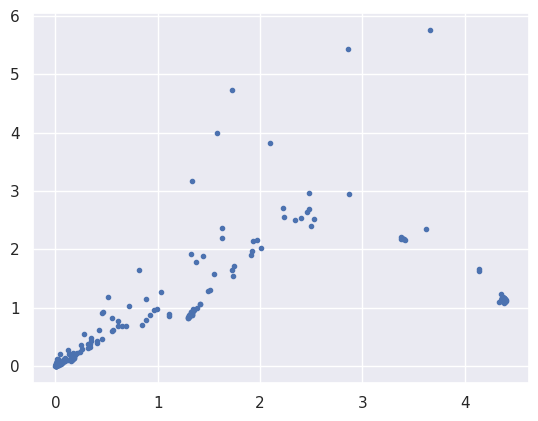

NameError: name 'r_grins_mean' is not defined

In [10]:
plt.plot(grins_mean,grins_var,".")
plt.show()
plt.plot(np.log(r_grins_mean),np.log(r_grins_var),".")
plt.show()

## Takeaway:
- Despite the smaller sample size, the data more or less looks the same for GRiNS as for Norman
- At the same time, the peak at the upper end of the GRiNS histogram is strange

# Find good metrics to predict `pct_dropout_by_counts`

## Calculate dropout stats:

In [11]:
norman_dropouts = np.asarray(norman_data.var["pct_dropout_by_counts"])
norman_mean_non_zero = np.asarray(norman_mean)/(1-norman_dropouts/100)
norman_isdropout = norman_data.var["pct_dropout_by_counts"]>99
norman_dropout_genes = list(norman_data.var[norman_isdropout].index)

In [12]:
adamson_mean = np.asarray(adamson_data.layers["log1p"].mean(axis=0)).squeeze()
adamson_dropouts = np.asarray(adamson_data.var["pct_dropout_by_counts"])
adamson_mean_non_zero = adamson_mean/(1-adamson_dropouts/100)

adamson_isdropout = adamson_data.var["pct_dropout_by_counts"]>99
adamson_dropout_genes = list(adamson_data.var[adamson_isdropout].index)

In [25]:
grins_dropouts = np.asarray(grins_data.var["pct_dropout_by_counts"])
grins_mean_non_zero = grins_mean/(1-grins_dropouts/100)
grins_isdropout = grins_data.var["pct_dropout_by_counts"]>99
grins_old_dropouts = np.asarray(grins_data_old.var["pct_dropout_by_counts"])
grins_old_isdropout = grins_data_old.var["pct_dropout_by_counts"]>99
grins_dropout_genes = list(grins_data.var[grins_isdropout].index)

In [14]:
def get_nonzero_stats(layer):
    layer = layer.tocsc()
    mean_nz = []
    var_nz = []
    skew_nz = []
    median_nz = []
    non_zero_entries = np.split(layer.indices,layer.indptr[1:-1])
    for i in range(len(non_zero_entries)):
        non_zero_exprs = (layer[non_zero_entries[i],i]).todense().T
        if non_zero_exprs.shape[1] < 1:
            mean_nz.append(0)
            var_nz.append(0)
            skew_nz.append(0)
            median_nz.append(0)
            continue
        mean_nz.append(np.mean(non_zero_exprs))
        var_nz.append(np.var(non_zero_exprs))
        skew_nz.append(stats.skew(non_zero_exprs,axis=1)[0])
        median_nz.append(np.median(non_zero_exprs,axis=1)[0,0])
    mean_nz = np.asarray(mean_nz)
    var_nz = np.asarray(var_nz)
    skew_nz = np.asarray(skew_nz)
    median_nz = np.asarray(median_nz)
    return {"mean":mean_nz, "var":var_nz, "skew":skew_nz, "median":median_nz}

In [18]:
norman_stats = get_nonzero_stats(norman_data.layers["log1p"])
adamson_stats = get_nonzero_stats(adamson_data.layers["log1p"])
grins_stats = get_nonzero_stats(grins_data.layers["log1p"])
grins_old_stats = get_nonzero_stats(grins_data_old.layers["log1p"])

In [ ]:
# Naive idea: find the percentage of non-zero cells
scipy.sparse.csr_matrix.getnnz(norman_data.X)/(norman_data.X.shape[0]*norman_data.X.shape[1])

0.09929338367154318

## Plot depending on isdropout:

### Plot dropout distribution:

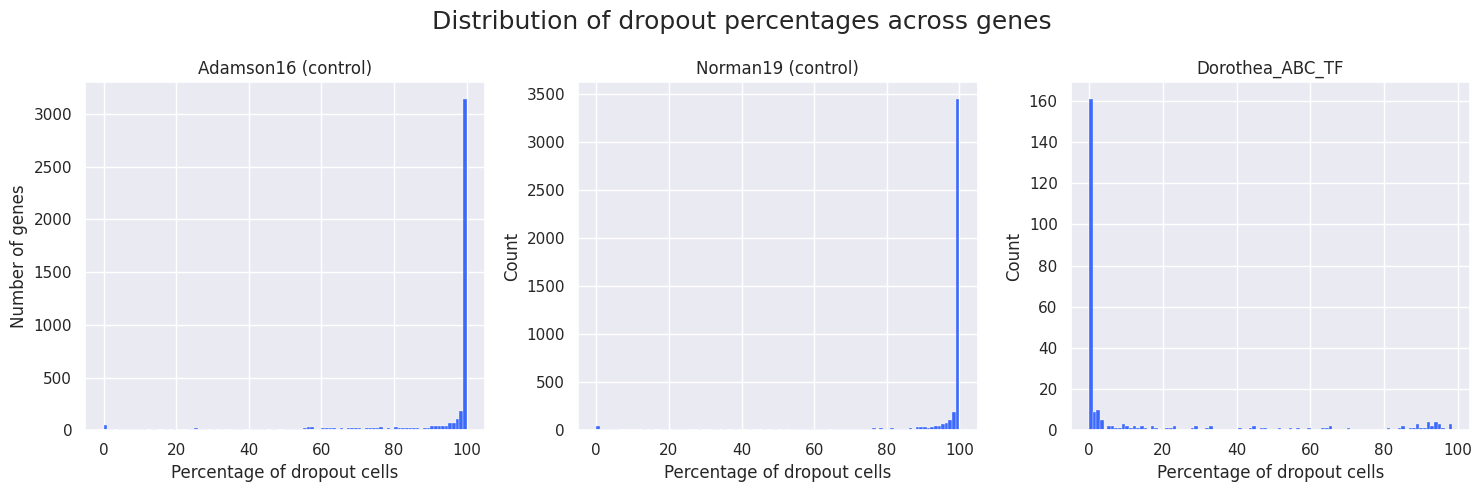

In [54]:
palette = sns.color_palette("bright")
with palette:
    fig,axs = plt.subplots(ncols=3,figsize=(15,5))
    sns.histplot(ax=axs[0],x=adamson_data.var["pct_dropout_by_counts"],bins=100)
    sns.histplot(ax=axs[1],x=norman_data.var["pct_dropout_by_counts"],bins=100)
    sns.histplot(ax=axs[2],x=grins_data_old.var["pct_dropout_by_counts"],bins=100)
    axs[0].set_title("Adamson16 (control)")
    axs[1].set_title("Norman19 (control)")
    axs[2].set_title("Dorothea_ABC_TF")
    axs[0].set_ylabel("Number of genes")
    for i in range(3):
        axs[i].set_xlabel("Percentage of dropout cells")
    fig.suptitle("Distribution of dropout percentages across genes",fontsize=18)
    fig.tight_layout()
    plt.savefig("Prep_Data/Plots/missingness_hist_old.png",dpi=300)
    plt.show()

In [ ]:
grins_data.X

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 174685667 stored elements and shape (1000000, 259)>

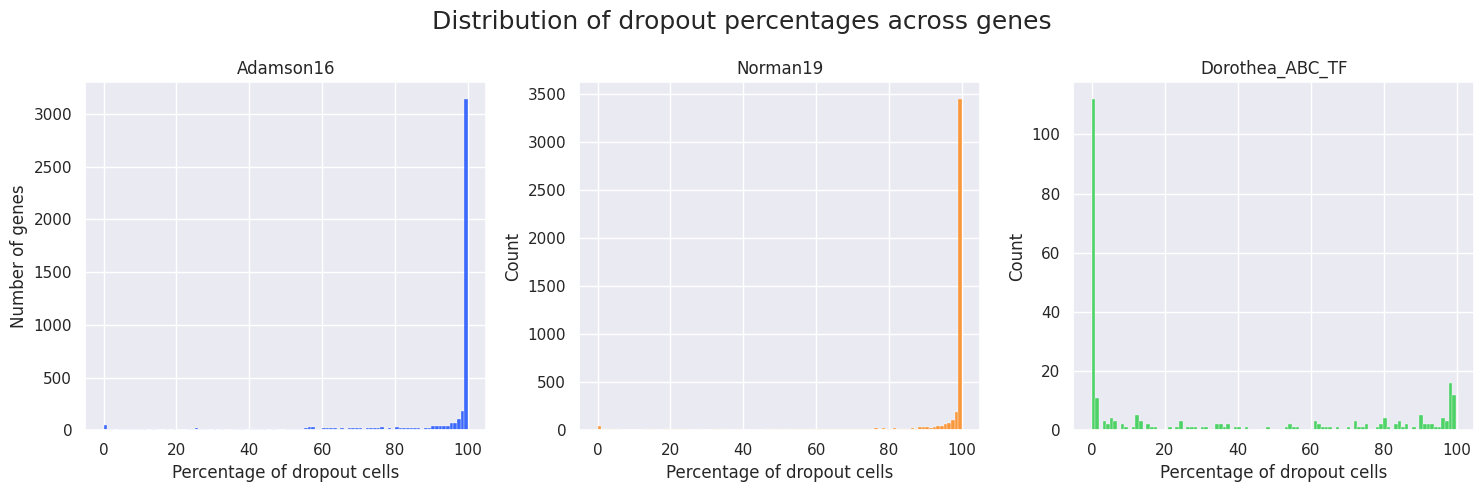

In [ ]:
palette = iter(sns.color_palette("bright"))
fig,axs = plt.subplots(ncols=3,figsize=(15,5))
sns.histplot(ax=axs[0],x=adamson_data.var["pct_dropout_by_counts"],bins=100,color=next(palette))
sns.histplot(ax=axs[1],x=norman_data.var["pct_dropout_by_counts"],bins=100,color=next(palette))
sns.histplot(ax=axs[2],x=grins_data_old.var["pct_dropout_by_counts"],bins=100,color=next(palette))
axs[0].set_title("Adamson16")
axs[1].set_title("Norman19")
axs[2].set_title("Dorothea_ABC_TF")
axs[0].set_ylabel("Number of genes")
for i in range(3):
    axs[i].set_xlabel("Percentage of dropout cells")
fig.suptitle("Distribution of dropout percentages across genes",fontsize=18)
fig.tight_layout()
plt.savefig("test.png",dpi=300)
plt.show()

In [ ]:
# Use nonzero stats to classify to separate zeroes
# Look at how missingness appears across cells (e.g. cells completely missing)
# 

### Plot various axes against each other:

/tmp/ipykernel_3753/1178898118.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


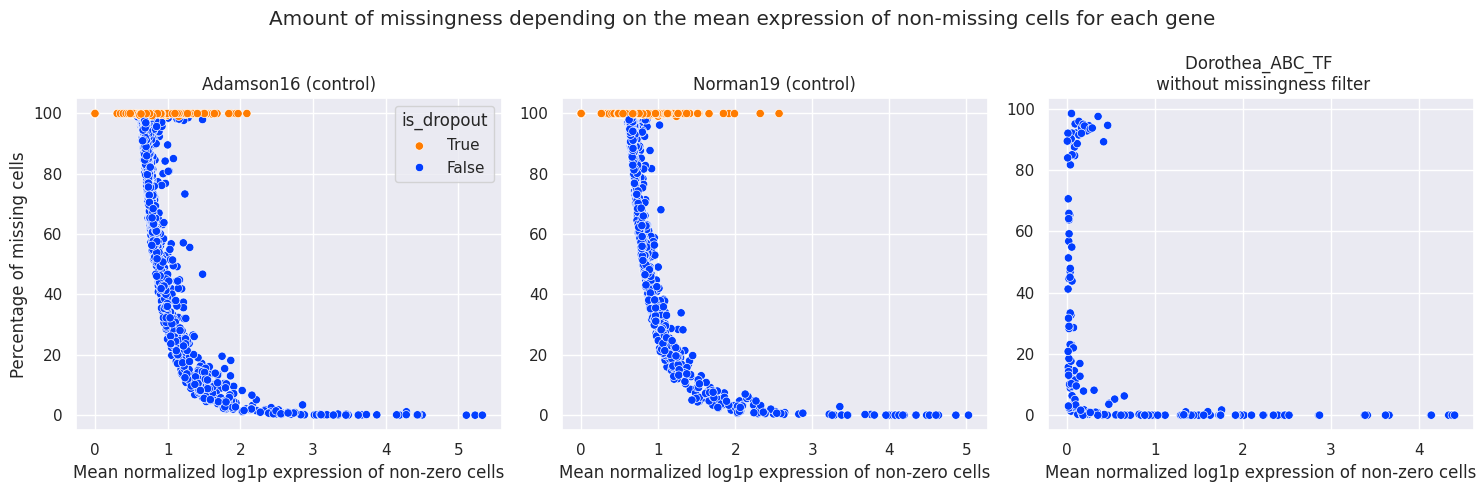

In [55]:
with palette:
    fig, axs = plt.subplots(ncols=3,figsize=(15,5))
    a = sns.scatterplot(ax=axs[0],x=adamson_stats["mean"],y=adamson_dropouts,hue=adamson_isdropout)
    n = sns.scatterplot(ax=axs[1],x=norman_stats["mean"],y=norman_dropouts,hue=norman_isdropout,legend=False)
    g = sns.scatterplot(ax=axs[2],x=grins_old_stats["mean"],y=grins_old_dropouts,hue=grins_old_isdropout,legend=False)
    a.legend(title="is_dropout",loc="upper right",labels=["True","False"])
    a.set_title("Adamson16 (control)")
    n.set_title("Norman19 (control)")
    g.set_title("Dorothea_ABC_TF \n without missingness filter")
    fig.suptitle("Amount of missingness depending on the mean expression of non-missing cells for each gene")
    axs[0].set_ylabel("Percentage of missing cells")
    for i in range(3):
        axs[i].set_xlabel("Mean normalized log1p expression of non-zero cells")
    fig.tight_layout()
    plt.savefig("Prep_Data/Plots/missingness_vs_mean_nz_old.png",dpi=300)
    fig.show()

/tmp/ipykernel_3753/434651187.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


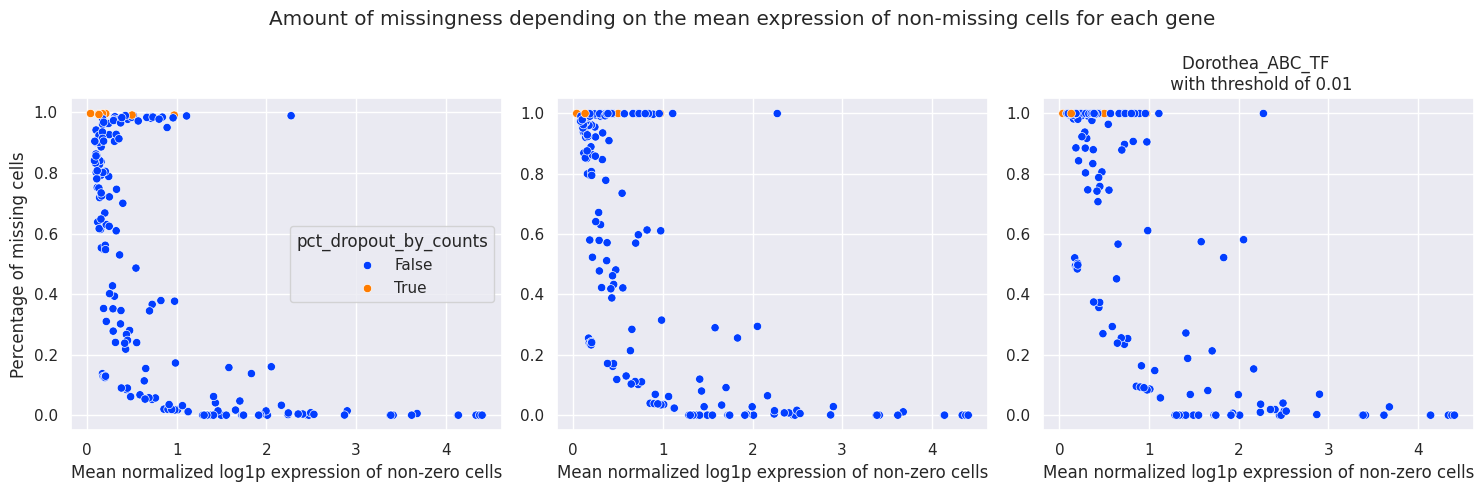

In [66]:
with palette:
    fig, axs = plt.subplots(ncols=3,figsize=(15,5))
    g = sns.scatterplot(ax=axs[0],x=grins_stats["mean"],y=1-(1-grins_dropouts/100)**1,hue=grins_isdropout)
    g = sns.scatterplot(ax=axs[1],x=grins_stats["mean"],y=1-(1-grins_dropouts/100)**2,hue=grins_isdropout,legend=False)
    g = sns.scatterplot(ax=axs[2],x=grins_stats["mean"],y=1-(1-grins_dropouts/100)**5,hue=grins_isdropout,legend=False)
    a.legend(title="is_dropout",loc="upper right",labels=["True","False"])
    a.set_title("Adamson16 (control)")
    n.set_title("Norman19 (control)")
    g.set_title("Dorothea_ABC_TF \n with threshold of 0.01")
    fig.suptitle("Amount of missingness depending on the mean expression of non-missing cells for each gene")
    axs[0].set_ylabel("Percentage of missing cells")
    for i in range(3):
        axs[i].set_xlabel("Mean normalized log1p expression of non-zero cells")
    fig.tight_layout()
    plt.savefig("Prep_Data/Plots/missingness_vs_mean_nz_002.png",dpi=300)
    fig.show()

### Takehome message:
- After designating cells with $<0.01$ expression as $0$, the nonzero_mean-pct_dropout-graph of grins looks very similar to the others

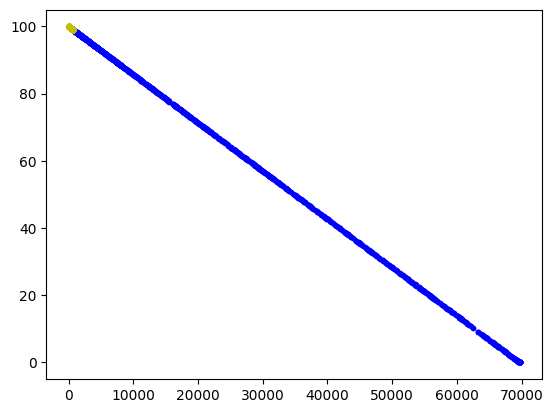

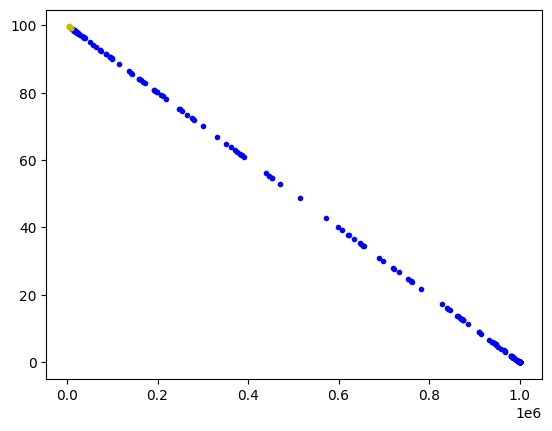

In [ ]:
plt.plot(norman_data.var.n_cells_by_counts[~norman_isdropout],norman_data.var.pct_dropout_by_counts[~norman_isdropout],".",c="b") # The problem with this approach is that there is no function mappable to this
plt.plot(norman_data.var.n_cells_by_counts[norman_isdropout],norman_data.var.pct_dropout_by_counts[norman_isdropout],".",c="y")
plt.show()
plt.plot(grins_data.var.n_cells_by_counts[~grins_isdropout],grins_data.var.pct_dropout_by_counts[~grins_isdropout],".",c="b") # The problem with this approach is that there is no function mappable to this
plt.plot(grins_data.var.n_cells_by_counts[grins_isdropout],grins_data.var.pct_dropout_by_counts[grins_isdropout],".",c="y")
plt.show()

### Plot axes but for non-zero stats:

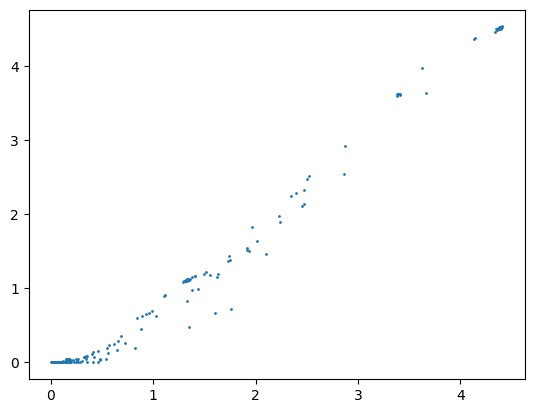

In [ ]:
plt.scatter(grins_mean_nz,grins_median_nz,s=1)
#plt.xlim(0,2)
#plt.ylim(0,2)
plt.show()

In [ ]:
def plot_nz_adamson_norman(xax, yax):
    s=1
    alpha=0.5

    fig, ax = plt.subplots(ncols=3,figsize=(15,5))
    for i, dataset, dropout in zip(range(3),[adamson_stats,norman_stats,grins_stats],[adamson_isdropout,norman_isdropout,grins_isdropout]):
        ax[i].scatter(dataset[xax][dropout],dataset[yax][dropout],s=s,c="y",alpha=alpha)
        ax[i].scatter(dataset[xax][~dropout],dataset[yax][~dropout],s=s,color="b",alpha=alpha)
        ax[i].set_xlim(0,2) # Not quite working as intended; mak isdropout variable
        ax[i].set_ylim(0,2)
    plt.show()

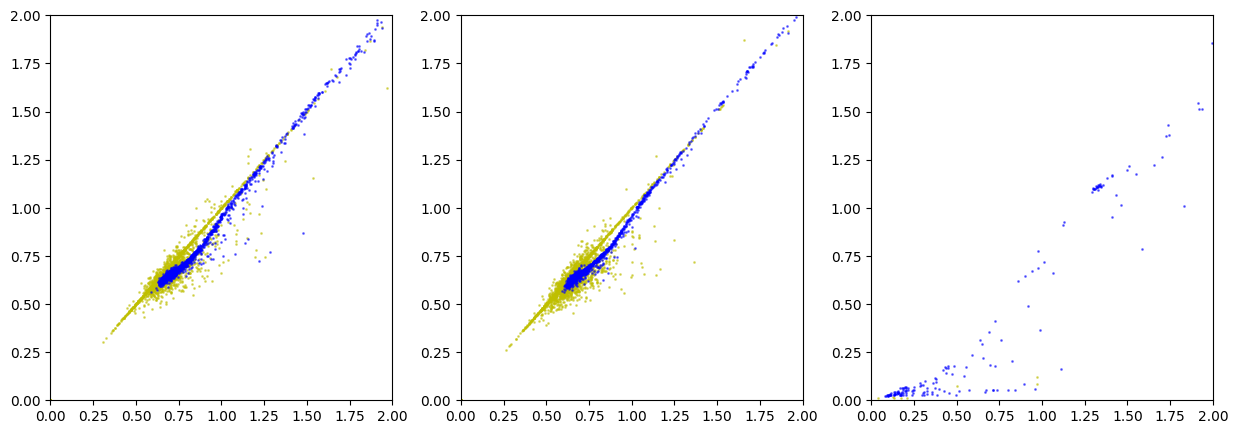

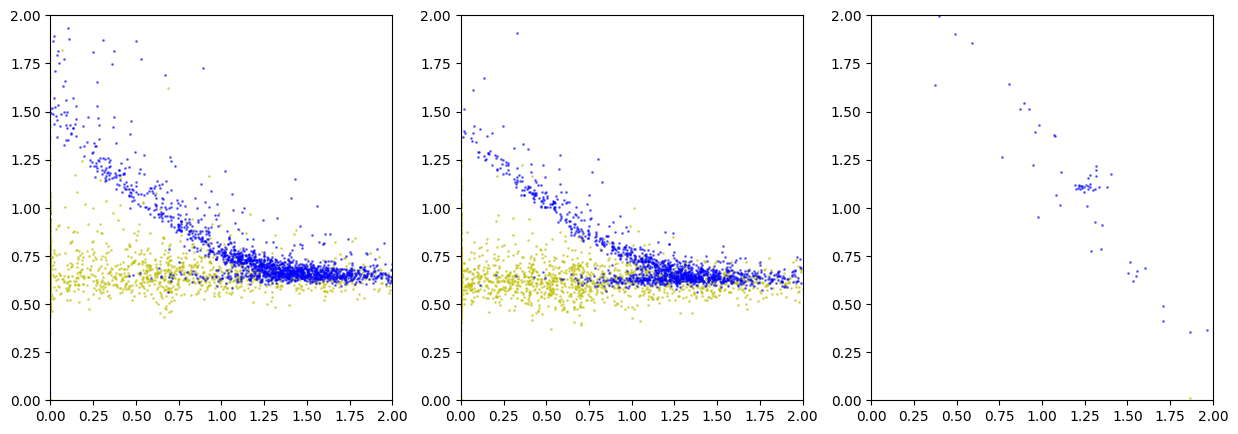

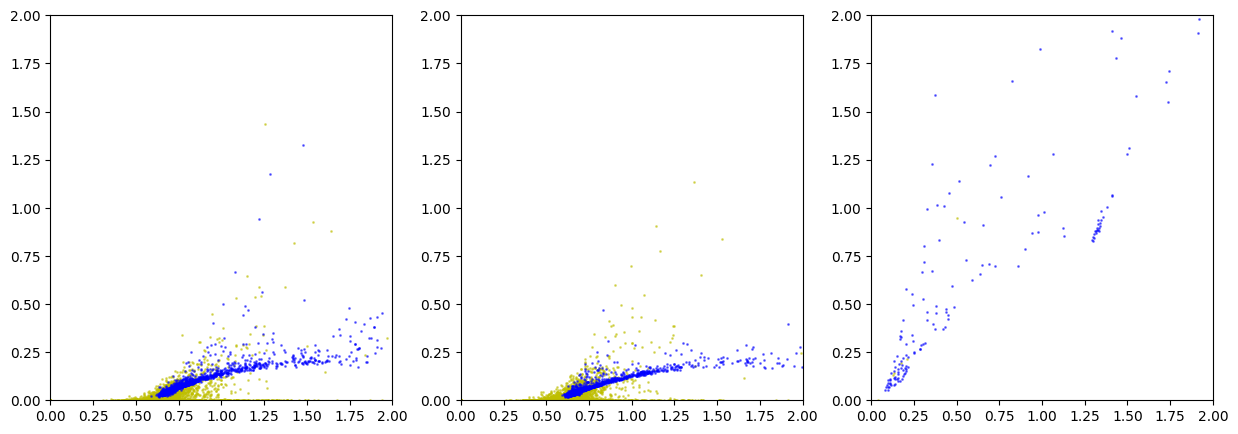

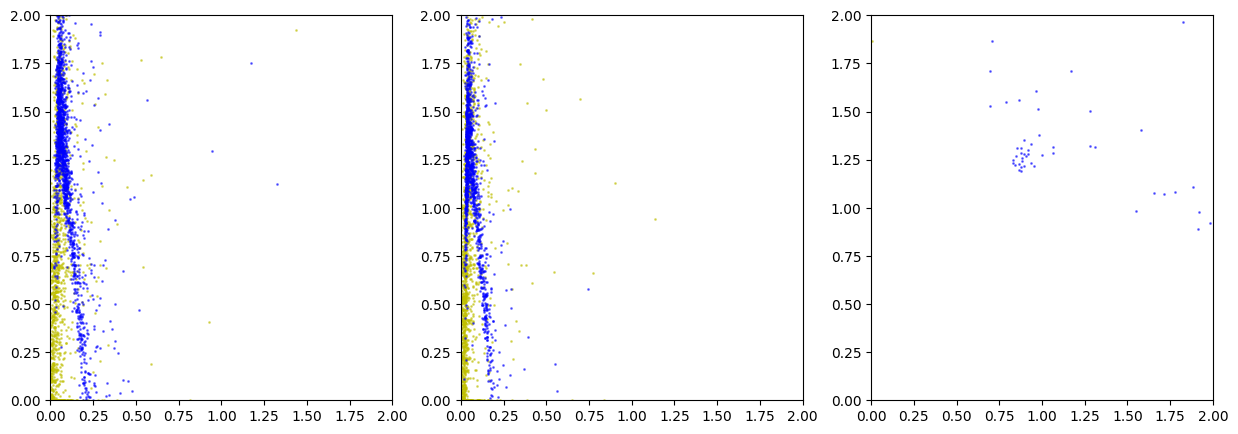

In [ ]:
plot_nz_adamson_norman("mean","median")
plot_nz_adamson_norman("skew","median")
plot_nz_adamson_norman("mean","var")
plot_nz_adamson_norman("var","skew")

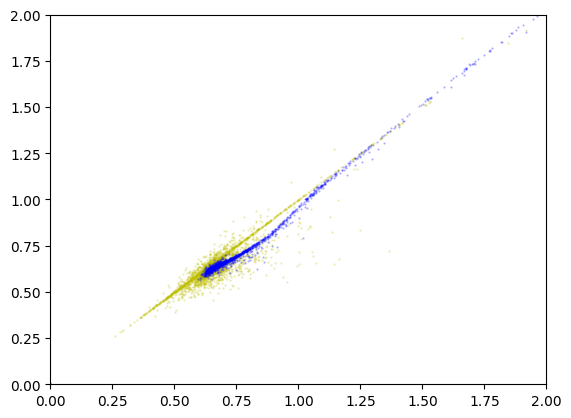

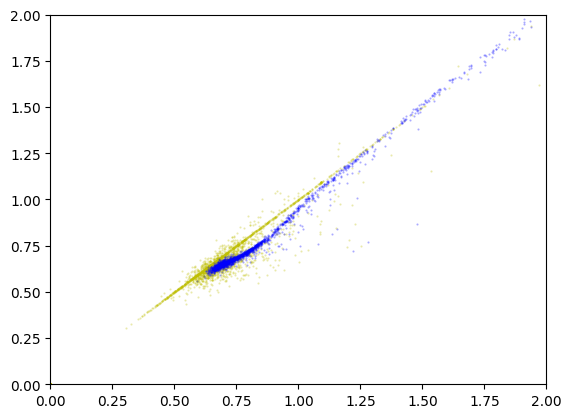

In [ ]:
plt.scatter(norman_mean_nz[norman_isdropout],norman_median_nz[norman_isdropout],s=0.3,c="y",alpha=0.3)
plt.scatter(norman_mean_nz[~norman_isdropout],norman_median_nz[~norman_isdropout],s=0.3,c="b",alpha=0.3)
plt.xlim(0,2)
plt.ylim(0,2)
plt.show()


plt.xlim(0,2)
plt.ylim(0,2)
plt.show()

### Try to fit a sigmoid curve:

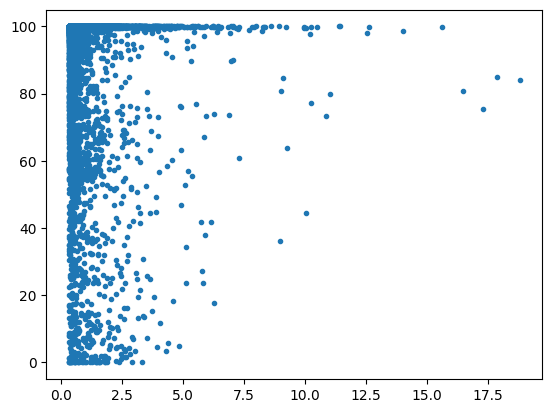

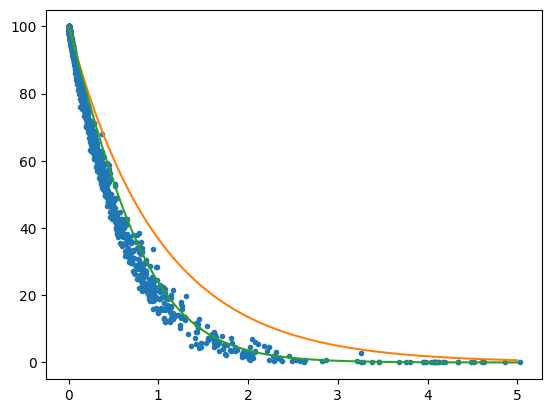

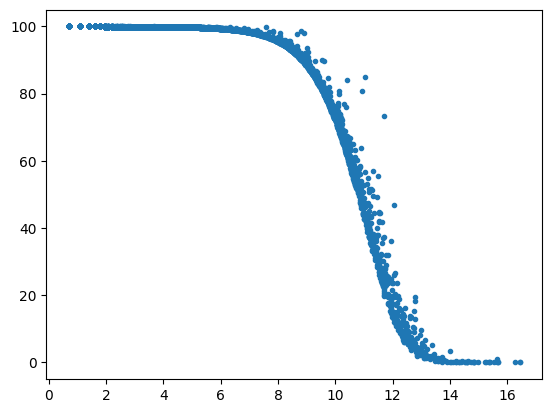

In [ ]:
plt.plot(adamson_data.var["dispersions_norm"],adamson_data.var["pct_dropout_by_counts"],".") # No correlation between dropout rate and dispersion
plt.show()
fig, ax = plt.subplots()
ax.plot(norman_mean,norman_data.var["pct_dropout_by_counts"],".") # dropout rate and mean counts related through gamma dist
x = np.linspace(0.001,5,1000)
k = 1
plt.plot(x,100*k*np.exp(-k*x))
plt.plot(x,100*2*1/(1+np.exp(-(-2)*x))) # Sigmoid works surprisingly well, but why? -> sigmoid is cdf of logistic dist
ax.plot()
plt.show()
plt.plot(adamson_data.var["log1p_total_counts"],adamson_data.var["pct_dropout_by_counts"],".") # dropout rate and total counts related through logit dist (or cumul gamma?)
plt.show()

## Try Regression:

In [ ]:
X_norman = np.asarray(norman_data.var[["n_cells_by_counts","log1p_mean_counts","log1p_total_counts","dispersions_norm"]])
X_norman = np.asarray(norman_data.var[["n_cells_by_counts"]])
#X_norman = np.asarray([norman_mean_non_zero]).T
y_norman = np.asarray(list(norman_isdropout),dtype=int)

X_train_norman = X_norman[~norman_isdropout]
X_test_norman = X_norman[norman_isdropout]
y_train_norman = y_norman[~norman_isdropout]
y_test_norman = y_norman[norman_isdropout]

In [ ]:
# Logistic Regression:
from sklearn.linear_model import LogisticRegression
logistic_norman = LogisticRegression(random_state=1,max_iter=100).fit(X_train_norman, y_train_norman)
print(logistic_norman.predict(X_train_norman[:10,:]),y_train_norman[:10])
print(1-(sum(logistic_norman.predict(X_train_norman)^y_train_norman))/len(y_train_norman)) # 100% correctly classified
print(logistic_norman.coef_,logistic_norman.intercept_)

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)

array([1, 1, 1, 1, 1, 0, 1, 0, 0, 1])

In [ ]:
# Fishers LDA:

np.int64(2354)

In [ ]:
clf

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
norman_data.var

,ensemble_id,ncounts,ncells,gene_name,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm
RP11-34P13.3,ENSG00000243485,29.0,29,RP11-34P13.3,False,False,False,20,0.000287,0.000287,99.971300,20.0,3.044523,True,0.000284,0.267977,0.308829
RP11-34P13.8,ENSG00000239945,10.0,10,RP11-34P13.8,False,False,False,8,0.000115,0.000115,99.988520,8.0,2.197225,True,0.000173,0.770738,2.072330
RP5-857K21.2,ENSG00000235146,3.0,3,RP5-857K21.2,False,False,False,1,0.000014,0.000014,99.998565,1.0,0.693147,True,0.000022,0.289630,0.384778
RP11-54O7.16,ENSG00000272438,41.0,41,RP11-54O7.16,False,False,False,24,0.000344,0.000344,99.965560,24.0,3.218876,True,0.000403,0.334074,0.540671
RP11-54O7.3,ENSG00000223764,976.0,937,RP11-54O7.3,False,False,False,499,0.007433,0.007406,99.283931,518.0,6.251904,True,0.007540,0.387897,0.729461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ATP6,ENSG00000198899,7457105.0,111420,MT-ATP6,True,False,False,69672,69.156204,4.250724,0.020090,4819219.0,15.388123,True,4.185784,1.497229,1.191991
MT-ND4,ENSG00000198886,11478554.0,111418,MT-ND4,True,False,False,69671,107.078133,4.682855,0.021525,7461847.0,15.825314,True,4.614620,1.729947,0.793016
MT-ND6,ENSG00000198695,539272.0,101559,MT-ND6,True,False,False,64388,5.059093,1.801560,7.602675,352548.0,12.772945,True,1.772451,0.998879,3.561519
MT-CYB,ENSG00000198727,5170633.0,111404,MT-CYB,True,False,False,69659,48.036938,3.892574,0.038745,3347502.0,15.023726,True,3.836050,1.306216,1.563828


## Discarded: Subclass of stats.rv_continuous for gamma-normal

In [ ]:
class gamma_normal_gen(stats.rv_continuous):
    "Gamma Distribution"
    def __init__(self):
        self.shapes="lamb, alpha, beta"
        self.a = 0.
    def _argcheck(self,x,lamb,alpha,beta):
        return (0<=lamb<=1) & (0<alpha<=10) & (0<beta<=10)
    def _pdf(self,x,lamb,alpha,beta):#,mu,sigma):
        return lamb*stats.gamma.pdf(x,alpha,scale=beta)#+(1-lamb)*(np.exp(-(x-mu)**2/(2*sigma**2))/np.sqrt(2.0*np.pi*sigma**2))#
    #def _shape_info(self):
    #    return [_ShapeInfo("lamb, alpha, beta", False, [(0,1),(0,10),(0,10)])]
    

In [ ]:
gn = gamma_normal_gen()#a=0.,shapes="lamb,alpha,beta")

In [ ]:
shapes = (0.5,1,0.5,0,1)
shapes = (0.5,1.0,0.5,1.0,1.0)

In [ ]:
gn.pdf(2,0.5,1.0,0.5)

AttributeError: 'gamma_normal_gen' object has no attribute '_parse_args'

In [ ]:
data = stats.gamma.rvs(1.0,1.0,size=10)

In [ ]:
stats.fit(gn,data,[(0,1),(0,3),(0,3)])

ValueError: Distribution `Distribution` is not yet supported by `scipy.stats.fit` because shape information has not been defined.

In [ ]:
stats.norm.rvs(1,1,size=10)

array([-0.07085624,  1.21153099,  1.46395751,  2.87962498,  0.57603295,
        1.94808404,  0.68883281,  2.03233699,  1.1937067 ,  1.36900526])

In [ ]:
gn.rvs(*shapes,size=10,random_state=np.random.default_rng())

/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2046: RuntimeWarning: overflow encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


ValueError: The function value at x=nan is NaN; solver cannot continue.

In [ ]:
stats.norm.pdf(1,0,2)

np.float64(0.17603266338214973)

## Maybe viable: Use optimize.minimize

In [ ]:
y_axis = adamson_data.var["log1p_mean_counts"].to_numpy()#np.linspace(0, 20, num=5_000)
pdf_y = adamson_data.var["pct_dropout_by_counts"].to_numpy()#two_gamma(y_axis, W, ALPHA1, SCALE1, ALPHA2, SCALE2) #w*g1 + (1-w)*g2

#Sample data for testing
Y = np.vstack([y_axis,pdf_y]).T[:500]

In [ ]:
dist = stats.expon
res = stats.fit(dist,y_axis)

FitParams(loc=np.float64(0.0), scale=np.float64(1.0))


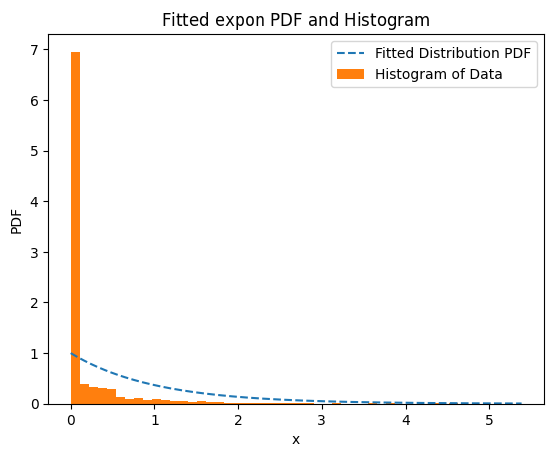

In [ ]:
res.plot()
print(res.params)

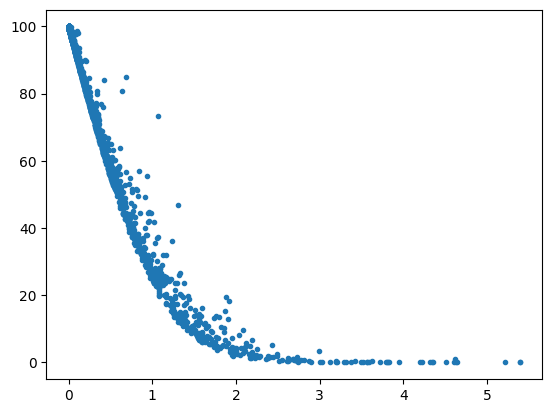

In [ ]:
plt.plot(y_axis,pdf_y,".")

In [ ]:
def gamma_normal(x, lamb, alpha, beta, mu, sigma):
    #Construct the current estimated PDF
    gamma_pdf = 100*stats.gamma.pdf(x, alpha, scale=beta)
    norm_pdf = 100*stats.norm.pdf(x,mu,scale=sigma)
    #norm_pdf = stats.norm.pdf(x,mu,sigma)
    y_pdf_estimate = lamb * gamma_pdf + (1 - lamb) * norm_pdf

    return y_pdf_estimate


In [ ]:
def gn_mle(params):
    y_pdf_estimate = gamma_normal(Y,*params)

    avg_neg_ll = -np.log(y_pdf_estimate+1e-8).mean()
    return avg_neg_ll

In [ ]:
initial_guess = [1]*5
bounds = [(0,1)]+[(0,None)]*4
results = scipy.optimize.minimize(gn_mle,x0=initial_guess,bounds=bounds)
estimated_params = (w, alpha1, scale1, alpha2, scale2) = results['x']

In [ ]:
y_pdf_fit = gamma_normal(adamson_data.var["log1p_mean_counts"][:500], *estimated_params)

In [ ]:
estimated_params

array([0.5])

(0.0, 300.0)

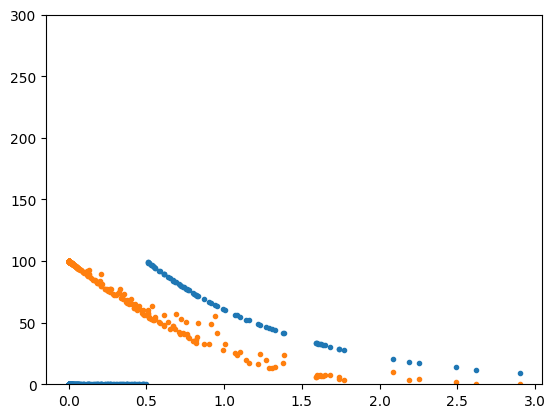

In [ ]:
fig, ax = plt.subplots()
ax.plot(y_axis[:500],y_pdf_fit,".")
ax.plot(y_axis[:500],pdf_y[:500],".")
ax.set_ylim(0,1)
#ax.plot(adamson_data.var["log1p_mean_counts"],adamson_data.var["pct_dropout_by_counts"],".")

## Other Resources:
- M3Drop: https://pmc.ncbi.nlm.nih.gov/articles/PMC6691329/
- scImpute: https://www.nature.com/articles/s41467-018-03405-7#Sec16
- MLE/EM: https://www.statlect.com/fundamentals-of-statistics/normal-distribution-maximum-likelihood
- scipy.fit: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.fit.html
- scipy.stats.rv_continuous: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.html#scipy.stats.rv_continuous
- Guide to new dists: https://docs.scipy.org/doc/scipy/dev/contributor/adding_new.html#adding-a-new-statistics-distribution
- Other peoples attempts:
    - https://stackoverflow.com/questions/78536889/how-to-implement-a-mixture-of-gamma-distributions-in-python-without-bayes
    - https://datascience.stackexchange.com/questions/131048/specifying-and-fitting-a-custom-distribution-to-data
- Logistic: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Sparsity in general: https://biocellgen-public.svi.edu.au/mig_2019_scrnaseq-workshop/handling-sparsity.html